# MAE Pre-training for Ultrasound ViT

This notebook trains a **Masked Autoencoder (MAE)** Vision Transformer from scratch on grayscale ultrasound images and plots training metrics live.

## Workflow
1. Load dataset
2. Configure model & training hyperparameters
3. **Train** with :func:`embeddings.vit.train.train_mae` (same code as ``train.py``): loss / LR plots each epoch
4. Visualise reconstructions
5. Extract sample embeddings


In [2]:
!ls /content

datasets_adapters  embeddings  sample_data


In [4]:
%matplotlib inline

import math, os, sys
from pathlib import Path

import torch
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

# Make sure project root is on the path
print(Path.cwd())
PROJECT_ROOT = str(Path.cwd().resolve().parents[0])  # two levels up from embeddings/vit/
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from embeddings.vit.train import (
    MAETrainTransform,
    MAEValTransform,
    train_mae,
    load_checkpoint,
    visualize_reconstruction,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


/content
Project root: /
PyTorch: 2.10.0+cu128
CUDA available: True


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load Dataset

Swap in any `torch.utils.data.Dataset` that returns grayscale images.
Uncomment the block that matches your data.


In [5]:
# ── Option A: Fetal Planes DB ──────────────────────────────────────
from datasets_adapters.fetal_planes_db.fpd_dataset import FetalPlanesDBDataset

DATASET_ROOT = "/content/drive/MyDrive/SHAD/project/fetal_planes_db"

# dataset = FetalPlanesDBDataset(root=DATASET_ROOT, images_dir='Images')

# ── Option B: Fetal Head Circumference ─────────────────────────────
from datasets_adapters.fetal_head_circ.fhc_dataset import FetalHeadCircDataset

FHC_IMAGES_DIR = "/content/drive/MyDrive/SHAD/project/fetal_head_circumference/training_set/training_set"
FHC_CSV = "/content/drive/MyDrive/SHAD/project/fetal_head_circumference/training_set_pixel_size_and_HC.csv"

# ── Option C: Both fetal_planes + fetal_head_circ combined ─────────
from torch.utils.data import ConcatDataset

# ── Option D: FOCUS (four-chamber cardiac ultrasound) ───────────────
from datasets_adapters.focus import FOCUSDataset

FOCUS_ROOT = "/content/drive/MyDrive/SHAD/project/focus"

# ── Option E: Abdominal Segmentation (images from .npy) ──────────────
from datasets_adapters.abdominal_segmentation import AbdominalSegmentationDataset

ABDOMINAL_ROOT = "/content/drive/MyDrive/SHAD/project/FetalAbdominalSegmentationDataset"

# Choose one:
# dataset = FetalPlanesDBDataset(root=DATASET_ROOT, images_dir='Images')
# dataset = FetalHeadCircDataset(images_dir=FHC_IMAGES_DIR, csv_file=FHC_CSV, load_annotations=False)
dataset = ConcatDataset([
    FetalPlanesDBDataset(root=DATASET_ROOT, images_dir='Images'),
    FetalHeadCircDataset(images_dir=FHC_IMAGES_DIR, csv_file=FHC_CSV, load_annotations=False),
    FOCUSDataset(root=FOCUS_ROOT, split="training", load_masks=False),
    AbdominalSegmentationDataset(root=ABDOMINAL_ROOT, load_masks=False)
])
# dataset = FOCUSDataset(root=FOCUS_ROOT, split="training", load_masks=False)
# dataset = AbdominalSegmentationDataset(root=ABDOMINAL_ROOT, load_masks=False)

# print(f"Dataset size: {len(dataset)} images")


Loaded 12400 images from /content/drive/MyDrive/SHAD/project/fetal_planes_db
Loaded 999 images from /content/drive/MyDrive/SHAD/project/fetal_head_circumference/training_set/training_set
Loaded 200 images from /content/drive/MyDrive/SHAD/project/focus/training
Loaded 1588 samples from /content/drive/MyDrive/SHAD/project/FetalAbdominalSegmentationDataset/ARRAY_FORMAT


## 2. Configuration


In [ ]:
# ── Model ──────────────────────────────────────────────────────────
MAX_IMAGE_HEIGHT = 224
PATCH_SIZE       = 16
EMBED_DIM        = 512
DEPTH            = 8
NUM_HEADS        = 8
DECODER_EMBED_DIM = 384
DECODER_DEPTH    = 6
DECODER_NUM_HEADS = 8
DECODER_PRED_NUM_LAYERS = 1
MLP_RATIO        = 4.0
NORM_PIX_LOSS    = True
CLIP_PIXEL_PRED  = False
L1_RATIO         = 0.9
FFT_LOSS_WEIGHT  = 0   # penalises missing high-frequency (texture) content; 0 = disabled

# ── Training ──────────────────────────────────────────────────────
EPOCHS           = 200
BATCH_SIZE       = 128
LR               = 1.5e-4
WEIGHT_DECAY     = 0.05
WARMUP_EPOCHS    = 10
MIN_LR           = 1e-5
MASK_RATIO       = 0.75   # MAE paper sweet spot; 0.6 made reconstruction too easy
VAL_SPLIT        = 0.1
NUM_WORKERS      = 8

# ── Checkpointing ─────────────────────────────────────────────────
CHECKPOINT_DIR   = os.path.join('/content/drive/MyDrive/SHAD/project', "checkpoints", "mae", "v17")
SAVE_EVERY       = 20          # save every N epochs
VISUALIZE_EVERY  = 10          # show reconstructions every N epochs
VIS_INDICES      = [42, 137, 1000, 1100]  # fixed dataset indices for reconstruction plots

# ── Device ─────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 4. Train MAE (`train_mae` from `embeddings/vit/train.py`)

This calls the same :func:`~embeddings.vit.train.train_mae` entry point as the training script. Checkpoints, `mae_final.pt`, and `mae_training_run.json` are written when `CHECKPOINT_DIR` is set.

The callback redraws loss / LR plots each epoch; every `VISUALIZE_EVERY` epochs it also saves reconstruction PNGs plus **raw metrics** (`mae_metrics_epochXXXX.csv`) and a **static metrics figure** (`mae_metrics_epochXXXX.png`) next to them via `dump_mae_training_metrics_artifacts`.


In [7]:
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

from embeddings.vit.train import dump_mae_training_metrics_artifacts


def update_plots(history: dict, epochs_total: int) -> None:
    """Redraw the live training dashboard (loss + LR)."""
    clear_output(wait=True)
    epochs_so_far = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    ax = axes[0]
    ax.plot(epochs_so_far, history["train_loss"], label="train", linewidth=1.5)
    ax.plot(epochs_so_far, history["val_loss"], label="val", linewidth=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Reconstruction Loss (MSE)")
    ax.set_title("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(epochs_so_far, history["train_loss"], label="train", linewidth=1.5)
    ax.plot(epochs_so_far, history["val_loss"], label="val", linewidth=1.5)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log)")
    ax.set_title("Loss (log scale)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    ax.plot(epochs_so_far, history["lr"], color="tab:orange", linewidth=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning Rate")
    ax.set_title("LR Schedule")
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    e = len(history["train_loss"])
    print(
        f"Epoch {e}/{epochs_total}  |  "
        f"train_loss = {history['train_loss'][-1]:.4f}  |  "
        f"val_loss = {history['val_loss'][-1]:.4f}  |  "
        f"lr = {history['lr'][-1]:.2e}"
    )


def on_epoch_end(epoch, history, model):
    update_plots(history, EPOCHS)
    if (epoch + 1) % VISUALIZE_EVERY == 0:
        vis_path = os.path.join(CHECKPOINT_DIR, f"reconstruction_epoch_{epoch + 1}.png")
        visualize_reconstruction(
            model,
            dataset,
            num_samples=len(VIS_INDICES),
            mask_ratio=MASK_RATIO,
            device=DEVICE,
            save_path=vis_path,
            sample_indices=VIS_INDICES,
        )
        dump_mae_training_metrics_artifacts(history, CHECKPOINT_DIR, epoch + 1)




In [8]:

model, history = train_mae(
    dataset,
    max_image_height=MAX_IMAGE_HEIGHT,
    patch_size=PATCH_SIZE,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    decoder_embed_dim=DECODER_EMBED_DIM,
    decoder_depth=DECODER_DEPTH,
    decoder_num_heads=DECODER_NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    clip_pixel_pred=CLIP_PIXEL_PRED,
    norm_pix_loss=NORM_PIX_LOSS,
    decoder_pred_num_layers=DECODER_PRED_NUM_LAYERS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    warmup_epochs=WARMUP_EPOCHS,
    min_lr=MIN_LR,
    mask_ratio=MASK_RATIO,
    val_split=VAL_SPLIT,
    num_workers=NUM_WORKERS,
    checkpoint_dir=CHECKPOINT_DIR,
    save_every=SAVE_EVERY,
    device=DEVICE,
    on_epoch_end=on_epoch_end,
    results_json=os.path.join(CHECKPOINT_DIR, "embed_history.json"),
    l1_loss_weight=L1_RATIO,
    l2_loss_weight=1 - L1_RATIO,
    fft_loss_weight=FFT_LOSS_WEIGHT,
)

Epoch 57/200  |  train_loss = 0.6480  |  val_loss = 0.6503  |  lr = 1.31e-04


: 

In [ ]:
from google.colab import runtime
print("Task completed. Terminating session...")
runtime.terminate()

## 6. Visualise Reconstructions


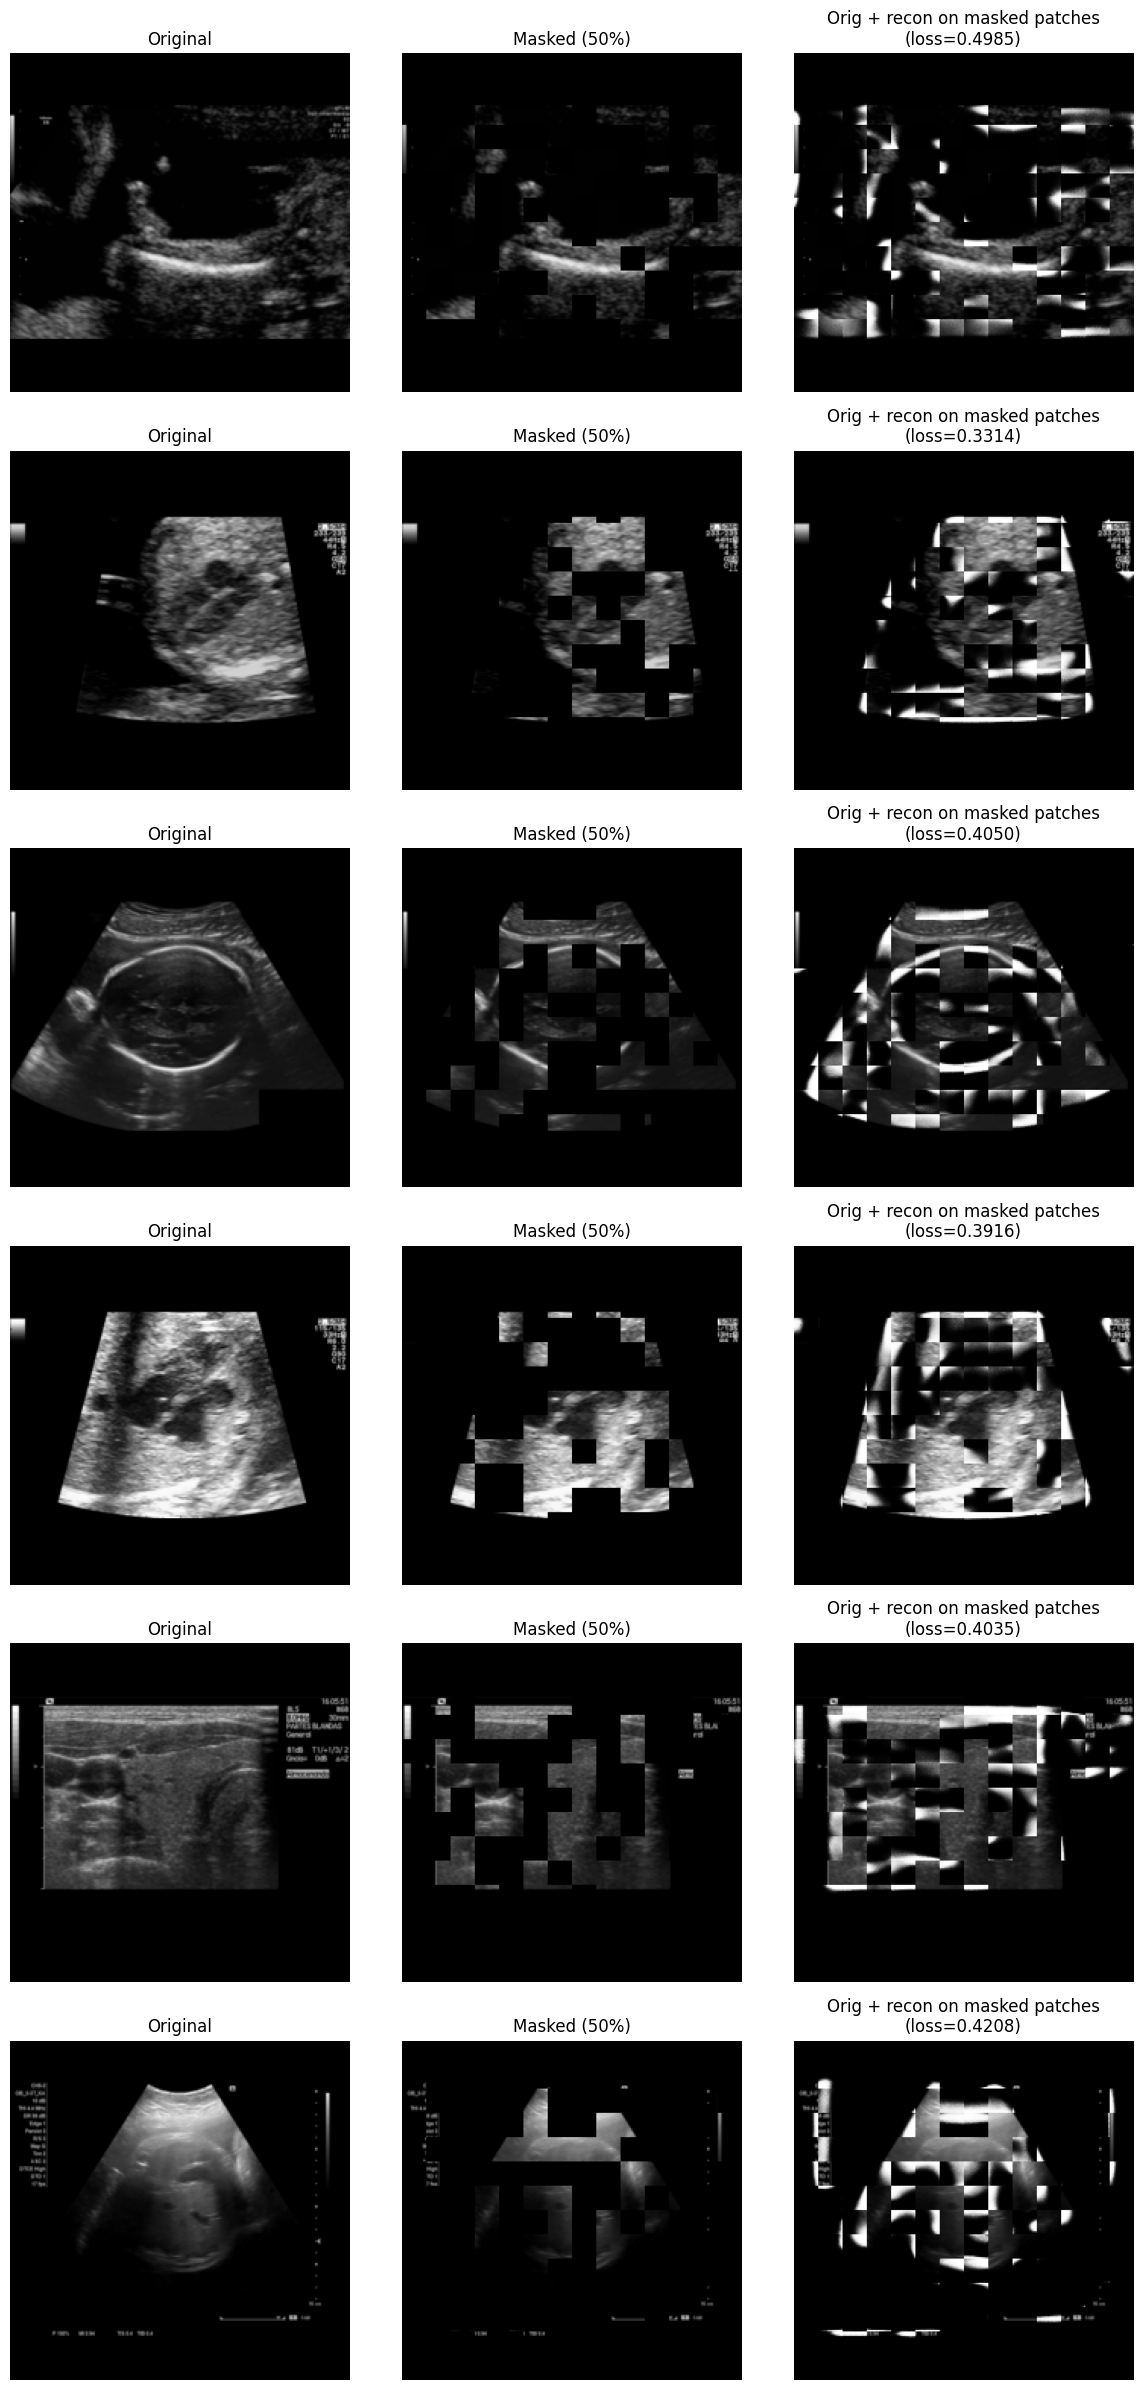

In [ ]:
visualize_reconstruction(
    model, dataset,
    num_samples=5,
    mask_ratio=MASK_RATIO,
    device=DEVICE,
    sample_indices=VIS_INDICES,
)


## 8. Resume training (optional)

Set ``RESUME_FROM`` to a checkpoint under ``CHECKPOINT_DIR``, then run the next cell. It calls ``train_mae(..., resume_from=...)`` — same as ``train.py``. You need ``on_epoch_end`` / ``update_plots`` from section 4 (re-run that cell if needed).


In [6]:
RESUME_FROM = os.path.join(CHECKPOINT_DIR, "mae_epoch_60.pt")

model, history = train_mae(
    dataset,
    max_image_height=MAX_IMAGE_HEIGHT,
    patch_size=PATCH_SIZE,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    decoder_embed_dim=DECODER_EMBED_DIM,
    decoder_depth=DECODER_DEPTH,
    decoder_num_heads=DECODER_NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    clip_pixel_pred=CLIP_PIXEL_PRED,
    norm_pix_loss=NORM_PIX_LOSS,
    decoder_pred_num_layers=DECODER_PRED_NUM_LAYERS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    warmup_epochs=WARMUP_EPOCHS,
    min_lr=MIN_LR,
    mask_ratio=MASK_RATIO,
    val_split=VAL_SPLIT,
    num_workers=NUM_WORKERS,
    checkpoint_dir=CHECKPOINT_DIR,
    save_every=SAVE_EVERY,
    device=DEVICE,
    on_epoch_end=on_epoch_end,
    results_json=os.path.join(CHECKPOINT_DIR, "embed_history.json"),
    l1_loss_weight=L1_RATIO,
    l2_loss_weight=1 - L1_RATIO,
    fft_loss_weight=FFT_LOSS_WEIGHT,
    resume_from=RESUME_FROM,
)

Epoch 59/200  |  train_loss = 0.6109  |  val_loss = 0.6142  |  lr = 5.96e-05


Epoch 119 [train]:  15%|█▌        | 16/106 [00:10<00:40,  2.22it/s, loss=0.5954]

: 

## 9. Linear probe evaluation (classification)

Evaluate the pre-trained encoder on the **Brain_plane** classification task: freeze the MAE encoder, add a linear head, and train only the head on fetal_planes_db. This measures how well the embeddings capture discriminative structure.

In [11]:
from datasets_adapters.fetal_planes_db.linear_probe import train_linear_probe

# Load a trained MAE checkpoint (or use any pretrained encoder)
encoder, _ = load_checkpoint(os.path.join(CHECKPOINT_DIR, "mae_final.pt"))
encoder.to(DEVICE)

# Train linear probe on fetal_planes_db Brain_plane classification
probe_history = train_linear_probe(
    encoder=encoder,
    embed_dim=EMBED_DIM,
    dataset_root=DATASET_ROOT,
    images_dir="Images",
    max_image_height=MAX_IMAGE_HEIGHT,
    epochs=100,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    device=DEVICE,
    checkpoint_dir=os.path.join(CHECKPOINT_DIR, "linear_probe"),
    save_every=10,
    num_workers=8,
    show_plot=True,
    
)

print(f"Best val accuracy: {100 * max(probe_history['val_acc']):.2f}%")

Loaded 7129 images from /content/drive/MyDrive/SHAD/project/fetal_planes_db
Loaded 7129 images from /content/drive/MyDrive/SHAD/project/fetal_planes_db
Loaded 5271 images from /content/drive/MyDrive/SHAD/project/fetal_planes_db


Epoch   1/100 | train_loss=1.2834 train_acc=55.31% train_bal_acc=31.41% | val_loss=1.3057 val_acc=51.75% val_bal_acc=33.77%


Epoch   2/100 | train_loss=0.9886 train_acc=64.88% train_bal_acc=41.91% | val_loss=1.2413 val_acc=54.32% val_bal_acc=38.58%


Epoch   3/100 | train_loss=0.9125 train_acc=67.54% train_bal_acc=45.29% | val_loss=1.1692 val_acc=57.58% val_bal_acc=46.22%


Epoch   4/100 | train_loss=0.8670 train_acc=69.34% train_bal_acc=47.88% | val_loss=1.1436 val_acc=58.05% val_bal_acc=44.72%


...

Epoch  33/100 | train_loss=0.5948 train_acc=79.03% train_bal_acc=62.24% | val_loss=0.9717 val_acc=63.88% val_bal_acc=50.64%


Epoch  34/100 | train_loss=0.5923 train_acc=79.25% train_bal_acc=62.42% | val_loss=0.9674 val_acc=63.65% val_bal_acc=50.71%


Epoch  35/100 | train_loss=0.5906 train_acc=79.12% train_bal_acc=62.34% | val_loss=0.9628 val_acc=64.26% val_bal_acc=50.10%


Epoch 36/100 [train]:  50%|████▉     | 55/111 [00:07<00:05, 11.16it/s, acc=78.54%, loss=0.5785]

: 

### Confusion matrix (Brain_plane, validation split)

Loads the saved linear-probe checkpoint, runs inference on the **validation** split, and plots the confusion matrix (counts and row-normalized fractions). Adjust `PROBE_CKPT` if your last epoch differs.

loaded checkpoint
Loaded 5271 images from /content/drive/MyDrive/SHAD/project/fetal_planes_db
constructed dataloader
gathered predictions


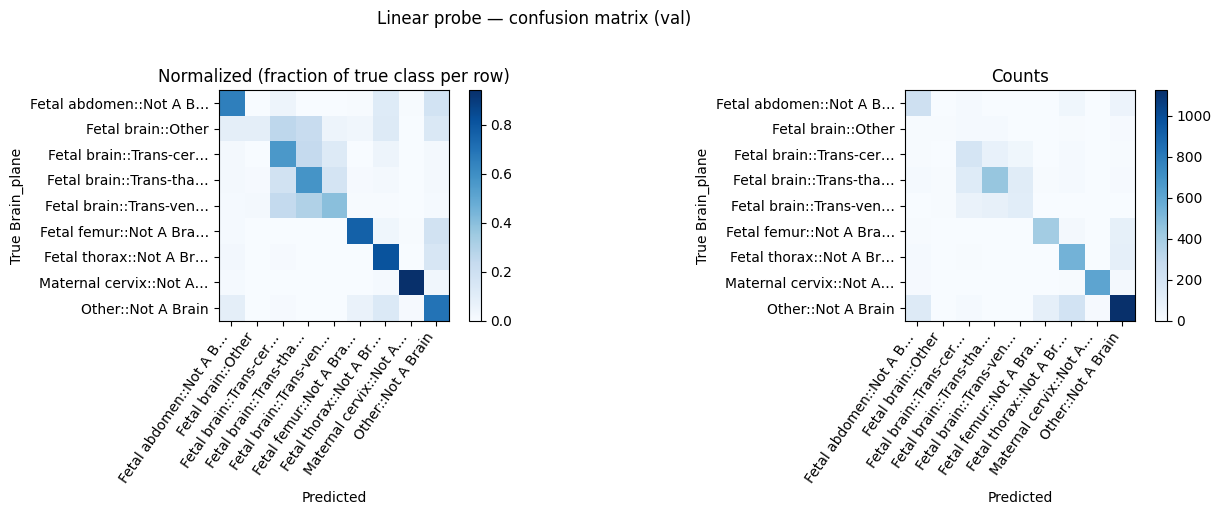

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from datasets_adapters.fetal_planes_db.linear_probe import (
    load_linear_probe_from_checkpoint,
    make_fetal_planes_probe_dataloader,
    linear_probe_gather_predictions,
    linear_probe_confusion_matrix,
)

# Match the checkpoint written by train_linear_probe (e.g. epoch 30)
PROBE_CKPT = os.path.join(CHECKPOINT_DIR, "linear_probe", "linear_probe_epoch_50.pt")

encoder_cm, _ = load_checkpoint(os.path.join(CHECKPOINT_DIR, "mae_final.pt"))
encoder_cm.to(DEVICE)
print('loaded checkpoint')
probe_model, class_to_idx = load_linear_probe_from_checkpoint(
    PROBE_CKPT, encoder_cm, EMBED_DIM, DEVICE,
)
num_classes = len(class_to_idx)
idx_to_class = {i: name for name, i in sorted(class_to_idx.items(), key=lambda x: x[1])}

val_loader_cm = make_fetal_planes_probe_dataloader(
    class_to_idx,
    DATASET_ROOT,
    images_dir="Images",
    max_image_height=MAX_IMAGE_HEIGHT,
    batch_size=64,
    num_workers=2,
    split="val",
)

print('constructed dataloader')

y_true, y_pred = linear_probe_gather_predictions(probe_model, val_loader_cm, DEVICE)
print('gathered predictions')
cm = linear_probe_confusion_matrix(y_true, y_pred, num_classes)
cm_norm = cm.astype(np.float64) / np.maximum(cm.sum(axis=1, keepdims=True), 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, num_classes * 0.35)))

for ax, mat, title in zip(
    axes,
    (cm_norm, cm),
    ("Normalized (fraction of true class per row)", "Counts"),
):
    im = ax.imshow(mat, interpolation="nearest", cmap="Blues")
    ticks = np.arange(num_classes)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    short = lambda s: (s[:22] + "…") if len(s) > 23 else s
    ax.set_xticklabels([short(idx_to_class[i]) for i in range(num_classes)], rotation=55, ha="right")
    ax.set_yticklabels([short(idx_to_class[i]) for i in range(num_classes)])
    ax.set_ylabel("True Brain_plane")
    ax.set_xlabel("Predicted")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Linear probe — confusion matrix (val)", y=1.02)
plt.tight_layout()
plt.show()

In [10]:
PROBE_CKPT = None

In [11]:
import json
import os

# Choose where to save, joining with checkpoint directory if available.
if PROBE_CKPT is not None:
    probe_ckpt_dir = os.path.dirname(PROBE_CKPT)
    results_path = os.path.join(probe_ckpt_dir, "probe_results_and_confusion_matrix.json")
else:
    results_path = "probe_results_and_confusion_matrix.json"

out = {
    "probe_history": probe_history,
    "confusion_matrix": cm.tolist(),
    "confusion_matrix_normalized": cm_norm.tolist(),
    "class_names": [idx_to_class[i] for i in range(num_classes)],
}

with open(results_path, "w") as f:
    json.dump(out, f, indent=2)

print(f"Saved probe_history and confusion matrix to {results_path}")

NameError: name 'cm' is not defined